In [2]:
import sys
print(sys.version)

3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]


In [3]:
%pip install requests beautifulsoup4 networkx matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
from bs4 import BeautifulSoup

# Seed URL
url = "https://en.wikipedia.org/wiki/Artificial_intelligence_in_healthcare"

response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

links = []

for link in soup.find_all("a"):
    href = link.get("href")
    
    if href and href.startswith("/wiki/") and ":" not in href:
        full_url = "https://en.wikipedia.org" + href
        links.append(full_url)

# Remove duplicates
links = list(set(links))

print("Total links found:", len(links))
print("First 10 links:")
for l in links[:10]:
    print(l)

Total links found: 0
First 10 links:


In [4]:
import requests
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/Computer-aided_diagnosis"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

links = []

for link in soup.find_all("a"):
    href = link.get("href")
    
    if href and href.startswith("/wiki/") and ":" not in href:
        full_url = "https://en.wikipedia.org" + href
        links.append(full_url)

links = list(set(links))

print("Total links found:", len(links))
print("First 10 links:")
for l in links[:10]:
    print(l)

Status Code: 200
Total links found: 163
First 10 links:
https://en.wikipedia.org/wiki/Biometrics
https://en.wikipedia.org/wiki/Outline_of_object_recognition
https://en.wikipedia.org/wiki/Naive_Bayes_classifier
https://en.wikipedia.org/wiki/Bayesian_probability
https://en.wikipedia.org/wiki/Visual_hull
https://en.wikipedia.org/wiki/Genomics
https://en.wikipedia.org/wiki/Bioimage_informatics
https://en.wikipedia.org/wiki/Artificial_neural_network
https://en.wikipedia.org/wiki/Magnetic_resonance_imaging
https://en.wikipedia.org/wiki/2D_to_3D_conversion


In [9]:
# Limit to first 100 links
links = links[:100]

seed = "https://en.wikipedia.org/wiki/Computer-aided_diagnosis"

# Remove seed if accidentally included
if seed in links:
    links.remove(seed)

print("Using", len(links), "linked pages")

Using 99 linked pages


In [10]:
import networkx as nx

G = nx.DiGraph()

# Add seed node
G.add_node(seed)

# Add first-level edges
for link in links:
    G.add_node(link)
    G.add_edge(seed, link)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 100
Edges: 99


In [11]:
print("Length of links list:", len(links))

Length of links list: 99


In [12]:
import time

for page in links:
    try:
        response = requests.get(page, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")
        
        for link in soup.find_all("a"):
            href = link.get("href")
            
            if href and href.startswith("/wiki/") and ":" not in href:
                full_url = "https://en.wikipedia.org" + href
                
                # Only connect inside our limited network
                if full_url in links:
                    G.add_edge(page, full_url)
        
        time.sleep(0.5)  # polite delay
        
    except:
        continue

print("Final nodes:", G.number_of_nodes())
print("Final edges:", G.number_of_edges())

Final nodes: 100
Final edges: 1270


In [13]:
print(type(G))

<class 'networkx.classes.digraph.DiGraph'>


In [14]:
print("Is strongly connected:", nx.is_strongly_connected(G))
print("Is weakly connected:", nx.is_weakly_connected(G))

Is strongly connected: False
Is weakly connected: True


In [15]:
# In-degree centrality
in_degree = nx.in_degree_centrality(G)

# Betweenness centrality
betweenness = nx.betweenness_centrality(G)

# PageRank
pagerank = nx.pagerank(G)

In [16]:
def get_top_n(metric_dict, n=20):
    return sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:n]

top_in_degree = get_top_n(in_degree)
top_betweenness = get_top_n(betweenness)
top_pagerank = get_top_n(pagerank)

print("Top 5 In-Degree:")
for node, score in top_in_degree[:5]:
    print(node, round(score, 4))

print("\nTop 5 Betweenness:")
for node, score in top_betweenness[:5]:
    print(node, round(score, 4))

print("\nTop 5 PageRank:")
for node, score in top_pagerank[:5]:
    print(node, round(score, 4))

Top 5 In-Degree:
https://en.wikipedia.org/wiki/ISBN_(identifier) 0.8687
https://en.wikipedia.org/wiki/ISSN_(identifier) 0.7374
https://en.wikipedia.org/wiki/PMC_(identifier) 0.6364
https://en.wikipedia.org/wiki/Bibcode_(identifier) 0.5859
https://en.wikipedia.org/wiki/ArXiv_(identifier) 0.4444

Top 5 Betweenness:
https://en.wikipedia.org/wiki/Medical_imaging 0.1666
https://en.wikipedia.org/wiki/Medical_image_computing 0.1344
https://en.wikipedia.org/wiki/Artificial_neural_network 0.0825
https://en.wikipedia.org/wiki/Facial_recognition_system 0.0712
https://en.wikipedia.org/wiki/Deep_learning 0.053

Top 5 PageRank:
https://en.wikipedia.org/wiki/ISBN_(identifier) 0.4027
https://en.wikipedia.org/wiki/ISSN_(identifier) 0.0601
https://en.wikipedia.org/wiki/PMC_(identifier) 0.046
https://en.wikipedia.org/wiki/Bibcode_(identifier) 0.0395
https://en.wikipedia.org/wiki/ArXiv_(identifier) 0.0354


In [17]:
# Remove identifier-related nodes
to_remove = []

for node in G.nodes():
    if any(keyword in node for keyword in [
        "ISBN", "ISSN", "PMC", "Bibcode", "arXiv", "identifier"
    ]):
        to_remove.append(node)

G.remove_nodes_from(to_remove)

print("Nodes after cleaning:", G.number_of_nodes())
print("Edges after cleaning:", G.number_of_edges())

Nodes after cleaning: 94
Edges after cleaning: 909


In [18]:
in_degree = nx.in_degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

In [19]:
def get_top_n(metric_dict, n=20):
    return sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:n]

top_in_degree = get_top_n(in_degree)
top_betweenness = get_top_n(betweenness)
top_pagerank = get_top_n(pagerank)

print("Top 5 In-Degree:")
for node, score in top_in_degree[:5]:
    print(node, round(score, 4))

print("\nTop 5 Betweenness:")
for node, score in top_betweenness[:5]:
    print(node, round(score, 4))

print("\nTop 5 PageRank:")
for node, score in top_pagerank[:5]:
    print(node, round(score, 4))

Top 5 In-Degree:
https://en.wikipedia.org/wiki/Facial_recognition_system 0.2688
https://en.wikipedia.org/wiki/Neural_radiance_field 0.2581
https://en.wikipedia.org/wiki/Computer_stereo_vision 0.2473
https://en.wikipedia.org/wiki/Object_detection 0.2473
https://en.wikipedia.org/wiki/Self-driving_car 0.2473

Top 5 Betweenness:
https://en.wikipedia.org/wiki/Medical_imaging 0.188
https://en.wikipedia.org/wiki/Medical_image_computing 0.1519
https://en.wikipedia.org/wiki/Artificial_neural_network 0.0929
https://en.wikipedia.org/wiki/Facial_recognition_system 0.08
https://en.wikipedia.org/wiki/Deep_learning 0.0592

Top 5 PageRank:
https://en.wikipedia.org/wiki/Food_and_Drug_Administration 0.0581
https://en.wikipedia.org/wiki/Bayesian_probability 0.0571
https://en.wikipedia.org/wiki/Medical_imaging 0.0308
https://en.wikipedia.org/wiki/Deep_learning 0.0288
https://en.wikipedia.org/wiki/Magnetic_resonance_imaging 0.0247


In [20]:
def clean_title(url):
    return url.split("/wiki/")[-1].replace("_", " ")

top_in_degree_clean = [(clean_title(node), score) for node, score in top_in_degree]
top_betweenness_clean = [(clean_title(node), score) for node, score in top_betweenness]
top_pagerank_clean = [(clean_title(node), score) for node, score in top_pagerank]

print("Top 5 In-Degree:")
for node, score in top_in_degree_clean[:5]:
    print(node, round(score, 4))

Top 5 In-Degree:
Facial recognition system 0.2688
Neural radiance field 0.2581
Computer stereo vision 0.2473
Object detection 0.2473
Self-driving car 0.2473


In [21]:
import pandas as pd

df_in = pd.DataFrame(top_in_degree_clean, columns=["Article", "InDegree"])
df_between = pd.DataFrame(top_betweenness_clean, columns=["Article", "Betweenness"])
df_pr = pd.DataFrame(top_pagerank_clean, columns=["Article", "PageRank"])

print("Top 10 In-Degree")
display(df_in.head(10))

print("\nTop 10 Betweenness")
display(df_between.head(10))

print("\nTop 10 PageRank")
display(df_pr.head(10))

Top 10 In-Degree


,Article,InDegree
0,Facial recognition system,0.268817
1,Neural radiance field,0.258065
2,Computer stereo vision,0.247312
3,Object detection,0.247312
4,Self-driving car,0.247312
5,3D reconstruction,0.236559
6,Eye tracking,0.225806
7,Blob detection,0.225806
8,Content-based image retrieval,0.225806
9,3D object recognition,0.225806



Top 10 Betweenness


,Article,Betweenness
0,Medical imaging,0.187969
1,Medical image computing,0.151887
2,Artificial neural network,0.092858
3,Facial recognition system,0.079969
4,Deep learning,0.059220
5,Magnetic resonance imaging,0.057739
6,Neural radiance field,0.046475
7,Pattern recognition,0.045782
8,Self-driving car,0.039138
9,Mammography,0.038180



Top 10 PageRank


,Article,PageRank
0,Food and Drug Administration,0.058106
1,Bayesian probability,0.057091
2,Medical imaging,0.030818
3,Deep learning,0.028804
4,Magnetic resonance imaging,0.024746
5,Mycin,0.023451
6,Normalization (image processing),0.022773
7,Computer stereo vision,0.020425
8,Pathology,0.019312
9,Facial recognition system,0.018946


In [22]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Density:", nx.density(G))

Number of nodes: 94
Number of edges: 909
Density: 0.10398078242964996


In [23]:
print("Sum of PageRank:", sum(pagerank.values()))

Sum of PageRank: 1.0


In [24]:
top5_pr_nodes = [node for node, score in top_pagerank[:5]]

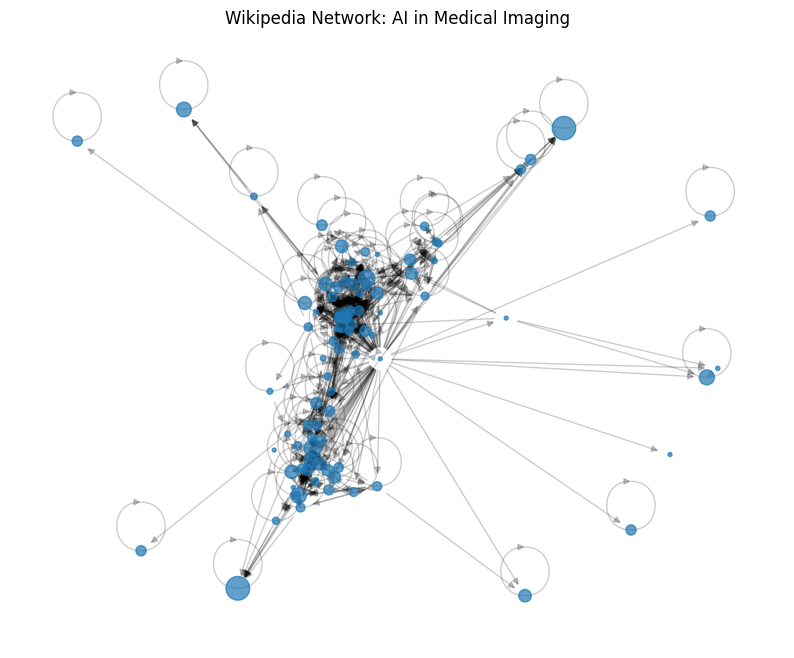

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

# Node sizes scaled by PageRank
node_sizes = [pagerank[node] * 5000 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2)

plt.title("Wikipedia Network: AI in Medical Imaging")
plt.axis("off")
plt.show()

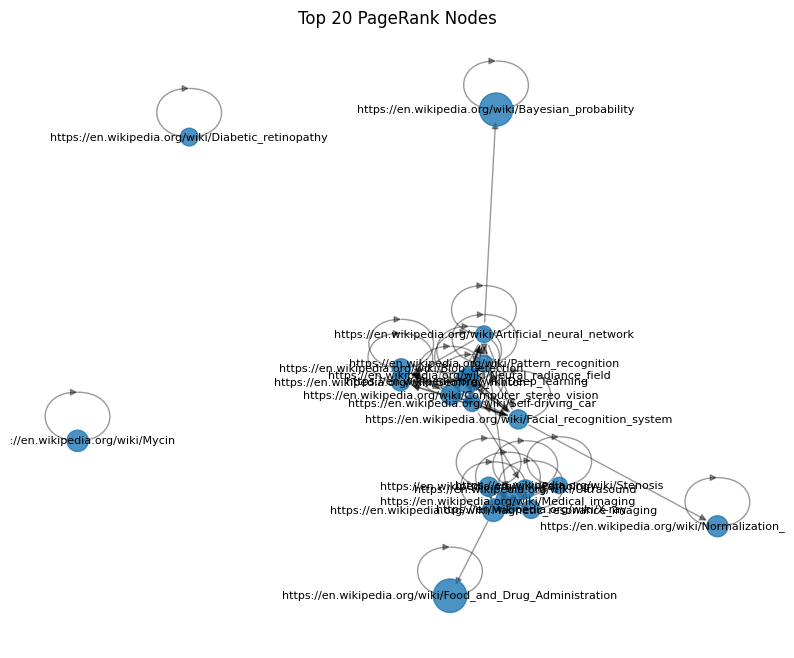

In [26]:
# Get top 20 nodes by PageRank
top20 = sorted(pagerank, key=pagerank.get, reverse=True)[:20]

# Create subgraph
G_top = G.subgraph(top20)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_top, seed=42)

node_sizes = [pagerank[node] * 10000 for node in G_top.nodes()]

nx.draw_networkx_nodes(G_top, pos, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G_top, pos, alpha=0.4)

labels = {node: node for node in G_top.nodes()}
nx.draw_networkx_labels(G_top, pos, font_size=8)

plt.title("Top 20 PageRank Nodes")
plt.axis("off")
plt.show()